In [40]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

# ADV QC
Steps, in the order they are applied:
1. clock drift correction (whole raw record, before anything else)
2. trim to in-water start/end, atmospheric pressure correction, configured salinity (sound speed)
3. beam quality masks (correlation, amplitude)
4. despiking
5. tilt / attitude
6. rotation to earth / shore-normal (on hold until the headings are verified)

Guidelines for QC taken from Holden's PUV QC workflow 
(`/Users/isidorarojas/Desktop/DIRECTORY/2026/NEVAEWA/Nortek_Vector_PUV_Pipeline`).

### 0. Sensor selection and parameters
VC1 is the test sensor. Every section reads `sensor_id` from the cell below, so a single run only
needs that one line changed. Once the pipeline is verified on VC1, list the other sensors in
`SENSORS` and use the batch cell at the end of the notebook ("Run the other sensors"), which
executes this notebook once per sensor and keeps an executed copy of each for review.

In [41]:
##-----sensor selection-----##
sensor_id = "VC1"
# Sensors for the batch cell at the end of the notebook. Only VC1 until the pipeline is verified.
# All processed Vectors: ["VA1", "VB1", "VC1", "VC2", "VD1", "VD2", "VE1", "VE2"]
# (VE1's clock drift is footnoted in sensor_notes.csv, so section 1 stops on it until that is resolved.)
SENSORS = ["VC1"]

##-----parameters-----##
# Everything tunable lives here.
# section 2: trim + pressure + sound speed
P_WET        = 3.0    # dbar. Below this the instrument is out of the water. In air it reads
                      # ~0.8-1.0 dbar and the shallowest Vector sits at ~4 m, so 3 dbar
                      # separates the two cleanly.
BUFFER_S     = 10     # s taken off each end of the window, AFTER the handling edges
HEAD_STD_MAX = 0.25   # deg. Floor of the handling threshold on the 1-min circular heading std
HEAD_STD_K   = 3.0    # threshold = max(HEAD_STD_MAX, HEAD_STD_K * median 1-min std of this sensor).
                      # Compass noise differs by sensor (median VC2 0.09 deg, VC1 0.23 deg), while
                      # handling gives > ~0.7 deg. The median, not the std, sets the scale: the
                      # handling minutes themselves inflate the std 20-30x (VC1: std 0.46, MAD 0.02).
CALM_MIN_MIN = 30     # min. A calm stretch must last this long to count as "deployed"
P_AIR        = 1.5    # dbar. Below this the instrument is in air, used for the in-air offset.
                      # Excludes readings taken while the frame hung below the boat (~2.6 dbar on VC2).
S_TRUE       = 35.0   # PSU, ASSUMED ambient salinity; the instrument was configured with 33.5.
                      # Replace with a measured value (CTD/RBR) if one exists.
RHO, GRAV    = 1023.0, 9.79   # kg/m3, m/s2 (21 N): dbar -> m of water, 1 dbar = 1e4 Pa

# section 3: beam quality
CORR_MIN         = 70     # %. Minimum beam correlation (Nortek recommendation, lab corrMin)
AMP_DB_PER_COUNT = 0.43   # dB per amplitude count (Nortek), for SNR = 0.43 * (amp - noise floor)
SNR_MIN          = 5.0    # dB. Low-SNR flag, diagnostic only unless APPLY_SNR
APPLY_SNR        = False  # True also NaNs velocity where any beam is below SNR_MIN

# paths: data/processed/qc/ for QC'd files, figs/qc/ for QC figures
data_path = "/Users/isidorarojas/Desktop/DIRECTORY/2026/4EWA/data/processed"
root    = Path(data_path).parents[1]              # .../4EWA
qc_dir  = Path(data_path) / "qc"
fig_dir = root / "figs" / "qc"
qc_dir.mkdir(exist_ok=True)
fig_dir.mkdir(parents=True, exist_ok=True)

# figure style, same palette as the orientation figures in adv_raw2nc.ipynb
INK, INK2, GRID, SERIES = "#0b0b0b", "#52514e", "#e4e3df", "#2a78d6"
BEAM_COLORS = ["#2a78d6", "#eb6834", "#1baf7a"]   # beams 1, 2, 3 (fixed order)
plt.rcParams.update({
    "axes.edgecolor": INK2, "axes.labelcolor": INK2, "xtick.color": INK2,
    "ytick.color": INK2, "axes.grid": True, "grid.color": GRID,
    "grid.linewidth": 0.6, "axes.spines.top": False, "axes.spines.right": False,
    "figure.facecolor": "white", "axes.facecolor": "white", "font.size": 9,
})

### 1. Clock Drift Correction
 - The standard approach is a linear drift from 0 at start to the measured drift at recovery, as linspace over the record. Check
   the CSV sign convention: negative means the sensor clock is slow, so corrected $ time = t − drift·(fraction elapsed)$ only when that sign is respected.

 - With no measured Vector drift:
   - Tide cross-correlation (NOAA Honolulu 1612340) catches time-zone and
     hour-scale
     offsets. Derive the lag sign as in PIPELINE_NOTES.md ("recovered filename
     clock is
     LOCAL time"). A lag scan alone can't tell ±. It does not resolve seconds.
   - VC2 vs ADCP are co-located (same lat/lon). Wave-band p–p cross-correlation
     gives
     seconds-level sync for VC2 against the ADCP, which has a known drift of −6
     s.
   - Other pairs (Vector vs nearby P-sensor): lag = propagation time + drift,
     so drift
     can only be bounded. Split lags over time: a drift trend across the
     deployment is
     separable from a constant propagation lag.

#### 1a. Load, drop seam fillers, linear drift correction

**Why this is first.** The drift builds up from when the clock was set (≈ the first raw sample,
on deck, before deployment), not from when the frame settled on the bed. Correcting the whole raw
record first means every later step (barometer interpolation, trim edges, tide check) works on
true UTC times.

1. **Drop seam filler records.** At each `.vec` file boundary, and after the recorder was stopped,
   the reader emits placeholder samples with `p = 0`, all beam correlations `= 0`, `temp = NaN`
   and a timestamp that duplicates the next real sample. Left in, they read as "out of water"
   mid-deployment. They are dropped, not interpolated.
2. **Linear drift.** The drift in `sensor_notes.csv` is the instrument clock minus PC internet
   time, measured at download. `+` = sensor clock fast, `-` = slow. The error builds up roughly
   linearly from when the clock was set (≈ first raw sample) to when it was checked (≈ last raw
   sample: logging stopped when the instrument was connected to the Nortek software). So each
   sample is shifted by
   `t_true = t - drift * (t - t_raw_start) / (t_raw_end - t_raw_start)`.
   This works for either sign: a fast clock (`+`) moves timestamps earlier, a slow one later.
   Timestamps are shifted, not resampled, so no data values change.

The tide-gauge check of the corrected clock needs the atmosphere-corrected pressure, so it runs
at the end of section 2 (2b).

In [42]:
##-----load raw + drop seam filler records-----##
# .load() pulls the whole file into memory (~400 MB for 10.7 M samples). Everything below
# indexes it repeatedly, and that is much faster in memory than lazily from disk.
ds_raw = xr.open_dataset(Path(data_path) / f"{sensor_id}.nc").load()
n_raw = ds_raw.sizes["time"]

# Seam fillers: pressure exactly 0, all three beam correlations 0, temp NaN, and a timestamp
# that duplicates the next real sample. They are not measurements, so drop them (no
# interpolation). Both conditions must hold, so a real low-correlation sample is never caught here.
filler = (ds_raw.p.values == 0) & (ds_raw["corr"].values == 0).all(axis=0)   # corr is (beam, time)
ds = ds_raw.isel(time=~filler)

# check the time base afterwards: spacing should be 0.5 s (2 Hz). Any > 0.5 s is a real gap
# where a filler replaced a sample, rather than duplicating one.
dt = np.diff(ds.time.values) / np.timedelta64(1, "s")
print(f"{sensor_id}: dropped {filler.sum()} filler samples "
      f"(p = 0, corr = 0) of {n_raw:,}")
print(f"  sample spacing after drop: min {dt.min():.3f} s, max {dt.max():.3f} s, "
      f"{(dt > 0.51).sum()} gap(s) > 0.5 s")

VC1: dropped 511 filler samples (p = 0, corr = 0) of 10,676,035
  sample spacing after drop: min 0.500 s, max 1.000 s, 2 gap(s) > 0.5 s


In [43]:
ds

<xarray.Dataset> Size: 502MB
Dimensions:              (x: 3, x*: 3, time: 10675524, beam: 3, earth: 3,
                          inst: 3)
Coordinates:
  * x                    (x) int64 24B 1 2 3
  * x*                   (x*) int64 24B 1 2 3
  * time                 (time) datetime64[ns] 85MB 2026-07-18T06:00:02.99999...
  * beam                 (beam) int64 24B 1 2 3
  * earth                (earth) <U1 12B 'E' 'N' 'U'
  * inst                 (inst) <U1 12B 'X' 'Y' 'Z'
Data variables:
    beam2inst_orientmat  (x, x*) float32 36B 2.706 -1.404 ... 0.3525 0.3281
    heading              (time) float32 43MB 217.9 217.9 217.9 ... 36.7 36.65
    pitch                (time) float32 43MB 19.3 19.35 19.4 ... -19.5 -19.45
    roll                 (time) float32 43MB -165.9 -165.9 ... -164.0 -164.0
    temp                 (time) float32 43MB 22.5 22.51 22.52 ... 26.65 26.65
    orientation_down     (time) bool 11MB True True True True ... True True True
    amp                  (beam, time) uint8 32MB 43 43 43 43 43 ... 46 46 47 46
    corr                 (beam, time) uint8 32MB 4 7 3 2 4 6 2 ... 4 3 3 7 6 4 8
    p                    (time) float32 43MB 0.648 0.647 0.648 ... 0.598 0.601
    u                    (time) float32 43MB 0.668 -5.74 -6.197 ... 1.418 -1.742
    v                    (time) float32 43MB 4.914 -0.725 1.766 ... -5.708 3.771
    w                    (time) float32 43MB 1.068 0.63 0.423 ... -0.036 0.489
Attributes: (12/59)
    inst_make:                   Nortek
    inst_model:                  Vector
    inst_type:                   ADV
    rotate_vars:                 vel
    n_beams:                     3
    profile_mode:                continuous
    ...                          ...
    status_code_counts:          0: 5338272; 217: 41; 233: 1; 241: 4239; 245:...
    orientation_down_constant:   True
    dropped_variables:           orientmat, batt, c_sound, error, status
    complex_vars:                []
    heading_kvh_magnetic_deg:    341.8
    heading_notes:               Matches compass heading from deployment (gopro)

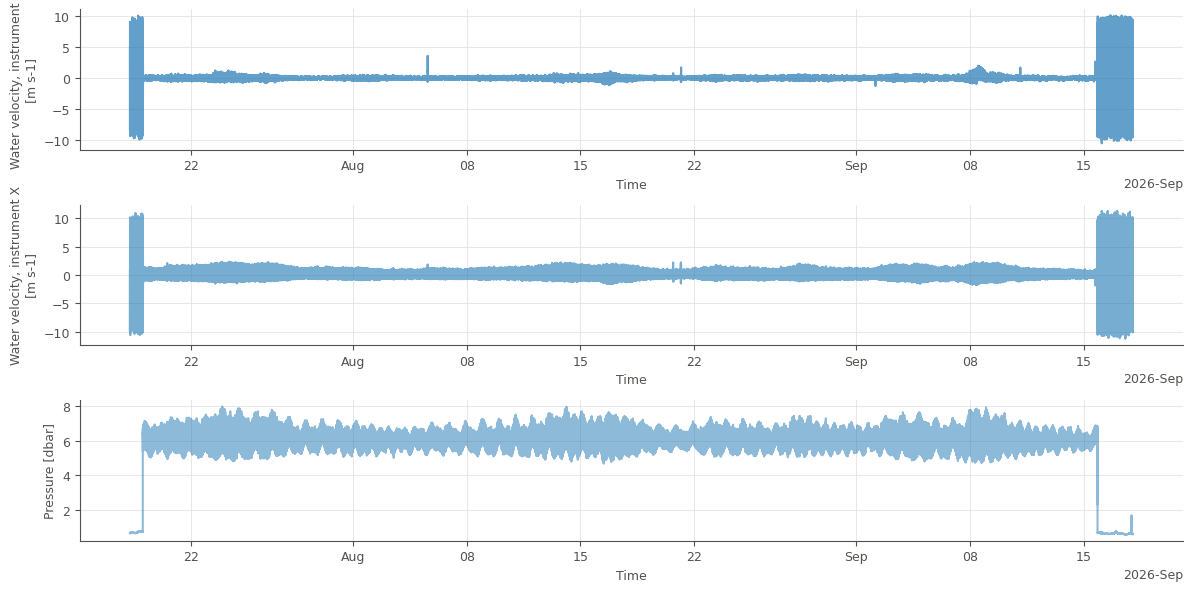

In [44]:
plt.figure(figsize=(12, 6))
plt.subplot(3,1,1)
ds['v'].plot(alpha=0.7)
plt.subplot(3,1,2)
ds['u'].plot(alpha=0.6)
plt.subplot(3,1,3)
ds['p'].plot(alpha=0.5)

plt.tight_layout()

In [45]:
##-----clock drift: linear correction-----##
# drift from the deployment notes. The column holds strings like "+3.571"; a trailing "*" marks a
# footnoted value (e.g. VE1, whose PC was on Hawaii time), so stop and read the footnote.
notes = pd.read_csv(root / "data" / "metadata" / "sensor_notes.csv", dtype=str, skipinitialspace=True)
notes.columns = notes.columns.str.strip()
row = notes[notes["Processed Data Sensor Name (.nc file)"].str.strip() == sensor_id].iloc[0]
drift_str = row["Clock Drift (seconds) over Deployment Duration***"].strip()
assert not drift_str.endswith("*"), f"{sensor_id} drift '{drift_str}' is footnoted; check sensor_notes.csv"
drift = float(drift_str)            # s; + = sensor clock fast, - = slow (CSV convention)

# The drift builds up over the whole time the clock ran, so the fraction elapsed is measured on
# the RAW record span: clock set ~ first sample, drift checked ~ last sample.
t_raw0, t_raw1 = ds_raw.time.values[[0, -1]]
t_old = ds.time.values
frac  = (t_old - t_raw0) / (t_raw1 - t_raw0)          # 0 at clock set -> 1 at drift check
shift = drift * frac                                    # s to subtract from each timestamp
ds = ds.assign_coords(time=t_old - np.round(shift * 1e9).astype("timedelta64[ns]"))

ds.attrs.update({
    "qc_clock_drift_s": drift,
    "qc_clock_drift_convention": "+ = sensor clock fast; t_true = t - drift * frac_elapsed",
    "qc_clock_raw_start": str(t_raw0),
    "qc_clock_raw_end": str(t_raw1),
    "qc_clock_applied": "before trimming, over the full raw record",
})

print(f"{sensor_id}: drift {drift:+.3f} s over the raw record {t_raw0} -> {t_raw1} "
      f"({(t_raw1 - t_raw0) / np.timedelta64(1, 'D'):.2f} days)")
print(f"  shift applied: {shift[0]:+.3f} s (first raw sample) to {shift[-1]:+.3f} s (last)")

VC1: drift +1.070 s over the raw record 2026-07-18T06:00:02.999992132 -> 2026-09-18T00:46:59.554846048 (61.78 days)
  shift applied: +0.000 s (first raw sample) to +1.070 s (last)


### 2. Trim to in water start/end

- use p < 3 dbars, plus a buffer of 10 seconds before and after to trim the data to when the instrument is in water.
- in air pressure at the start will give the original pressure-sensor offset. **However** due to low pressure from moving hurricanes, the atmospheric pressure may have to be adjusted during mid deployment. Pull barometric pressure from NOAA
- Sound speed/salinity corrections 

Notes:
1. **Drop seam filler records**: Each .vec file has a 1s seam filler where p=0 and all beam corrs =0. Dropped in section 1.

2. **Trip to in water**
    - *pressure*: use p < 3 dbars, plus a buffer of 10 seconds before and after to trim the data to when the instrument is in water.
    - *handling edges*: Compute the std of the heading. If the std > 0.25 deg over 60s, assume the instrument is being handled and trim that data. 
3. **Atmospheric Pressure**: take `Patm(t)` from NOAA COOPS barometer at station 1612340, Honolulu Harbor (21.3033 N, 157.8645 W; ~18 km E of VC2), interpolated to each sample.

#### 2a. Trim + pressure/sound-speed corrections

Input is the drift-corrected record from section 1. What these cells do, in order:
1. **In-water window, two stages.**
   - *Pressure edges:* the longest contiguous run with `p >= P_WET`. Using the longest run, not
     the first/last wet sample, ignores lone handling blips after recovery (VC2 had one 3.1 dbar
     sample on 09-18).
   - *Handling edges:* the pressure edges keep diver handling. Divers can move the frame after it
     lands (VC2: heading swung 95 → 32 deg in the first 40 min) and handle it before the lift.
     Undisturbed, the 1-min heading std is ~0.1 deg on VC2 but ~0.23 deg on VC1; handling gives
     > ~0.7 deg. So the threshold is relative to each sensor's own compass noise:
     `max(HEAD_STD_MAX, HEAD_STD_K × median 1-min std)` (0.27 deg on VC2, 0.68 deg on VC1). The
     median is used rather than the std because the handling minutes inflate the std 20–30×.
     The window is shrunk to the first/last **calm** run (1-min std < threshold) lasting at least
     `CALM_MIN_MIN`. A disturbance must last at least 2 min to count, which ignores isolated
     one-sample compass glitches. `BUFFER_S` is then taken off each end.
2. **Atmospheric pressure.** The Vector reads `p_raw = P_abs - C`, with `C` a fixed internal offset.
   In air, `C = Patm - p_raw`, so `p = p_raw + C - Patm(t)` (water pressure only). `Patm(t)` is the
   hourly NOAA CO-OPS barometer at station 1612340, Honolulu Harbor (21.3033 N, 157.8645 W;
   ~18 km E of the array), interpolated to each sample. The drift-corrected clock is taken as UTC.
   The evidence is the tide-gauge lag in 2b (≈ 0 min), which would be ±600 min for a Hawaii-time clock.
   `C` is the median of `Patm - p_raw` over the pre-deployment in-air samples (`p_raw < P_AIR`,
   5 min clear of the splash). The same number from the post-recovery in-air samples gives the
   sensor-zero drift `C_pre - C_post`, which is reported but **not applied**. Waves are unaffected;
   only the absolute mean level depends on `C`.
3. **Sound speed.** The Vector computed c from its own temperature and the configured salinity
   (33.5), and velocity scales linearly with c. Rescale by `c(T, S_TRUE) / c(T, 33.5)` using
   Medwin (1975). `S_TRUE` is an **assumed** open-coast value; replace it with a measured salinity
   if one exists. The effect is only ~0.1 %.

In [46]:
##-----in-water window-----##
# Two stages:
#   1. PRESSURE edges: when the instrument is physically underwater (p >= P_WET).
#   2. HANDLING edges: when it is sitting undisturbed on the bed. Divers move and adjust the
#      frame after it lands and before it is lifted. That shows up as heading jitter, not
#      pressure, so the window is pulled in to where the heading is steady.
t = pd.DatetimeIndex(ds.time.values)
p_raw = ds.p.values
wet = p_raw >= P_WET

def runs(mask):
    # (start, stop) index pairs of True runs, stop inclusive.
    # Padding with 0 on both sides makes diff = +1 at every run start and -1 one past every end.
    e = np.flatnonzero(np.diff(np.r_[0, mask.astype(int), 0]))
    return e[::2], e[1::2] - 1

# --- stage 1: pressure edges ---
# Take the LONGEST wet run rather than the first/last wet sample: a lone post-recovery
# handling blip (VC2: one 3.1 dbar sample on 09-18) would otherwise stretch the window by days.
starts, stops = runs(wet)
k = np.argmax(stops - starts)
i_in, i_out = starts[k], stops[k]          # indices of first/last wet sample of the deployment
for a, b in zip(starts, stops):
    print(f"  wet run {t[a]} -> {t[b]}  ({(t[b] - t[a]) / pd.Timedelta(hours=1):,.1f} h)")

# --- stage 2: handling edges ---
# Heading is an angle, so average it on the unit circle: 1-min means of sin and cos, then
# circular std = sqrt(-2 ln R), where R is the mean resultant length (R = 1 means no spread).
# A plain std would blow up whenever the heading crosses 0/360.
hr = np.radians(ds.heading.values[i_in:i_out + 1])
hm = (pd.DataFrame({"s": np.sin(hr), "c": np.cos(hr)}, index=t[i_in:i_out + 1])
        .resample("1min").mean())
R = np.hypot(hm.s, hm.c).clip(upper=1)      # clip guards log() against float round-off above 1
head_std = pd.Series(np.degrees(np.sqrt(-2 * np.log(R))), index=hm.index)

# A minute is "busy" if its heading std exceeds the threshold AND a neighbouring minute
# does too. Requiring >= 2 minutes in a row ignores the isolated one-sample compass glitches
# (~16 deg) that appear mid-record and have nothing to do with handling.
# Threshold relative to this sensor's own compass noise (median over the wet run; the handling
# minutes are too few to move the median), with HEAD_STD_MAX as a floor.
head_thr = max(HEAD_STD_MAX, HEAD_STD_K * float(head_std.median()))
busy = (head_std > head_thr).values
busy = busy & (np.r_[busy[1:], False] | np.r_[False, busy[:-1]])

# Calm runs lasting at least CALM_MIN_MIN minutes. The FIRST one marks the frame settling
# after deployment, the LAST one the final undisturbed minute before recovery. Anything in
# between (storms, fish, the VD2-style heading steps) is left for the tilt/attitude QC.
c0, c1 = runs(~busy)
long_calm = (c1 - c0 + 1) >= CALM_MIN_MIN
if not long_calm.any():
    raise RuntimeError(f"{sensor_id}: no calm run >= {CALM_MIN_MIN} min at heading std < {head_thr:.2f} deg; "
                       "inspect head_std before changing HEAD_STD_K / CALM_MIN_MIN")
first, last = np.flatnonzero(long_calm)[[0, -1]]
t_calm_in  = head_std.index[c0[first]]
t_calm_out = head_std.index[c1[last]] + pd.Timedelta(minutes=1)   # end of that minute bin

# final window: the tighter of the two edges, then the fixed buffer
t_in  = max(t[i_in],  t_calm_in)  + pd.Timedelta(seconds=BUFFER_S)
t_out = min(t[i_out], t_calm_out) - pd.Timedelta(seconds=BUFFER_S)

print(f"pressure edges : {t[i_in]}  ->  {t[i_out]}")
print(f"handling edges : {t_calm_in}  ->  {t_calm_out}   "
      f"(1-min heading std: deployed median {np.median(head_std[~busy]):.2f} deg, "
      f"threshold {head_thr:.2f} deg)")
print(f"in-water window: {t_in}  ->  {t_out}")
print(f"  handling removed: {(t_in - t[i_in]) / pd.Timedelta(minutes=1):.1f} min at deployment, "
      f"{(t[i_out] - t_out) / pd.Timedelta(minutes=1):.1f} min at recovery")

  wet run 2026-07-19 00:57:57.486307055 -> 2026-09-15 20:24:54.509700095  (1,411.4 h)
  wet run 2026-09-15 20:26:46.009685613 -> 2026-09-15 20:29:14.009665960  (0.0 h)
pressure edges : 2026-07-19 00:57:57.486307055  ->  2026-09-15 20:24:54.509700095
handling edges : 2026-07-19 01:46:00  ->  2026-09-15 19:43:00   (1-min heading std, deployed median 0.23 deg)
in-water window: 2026-07-19 01:46:10  ->  2026-09-15 19:42:50
  handling removed: 48.2 min at deployment, 42.1 min at recovery


In [47]:
##-----atmospheric pressure + in-air offset-----##
# The Vector's pressure sensor measures ABSOLUTE pressure minus a fixed internal offset C:
#     p_raw = P_abs - C,   with P_abs = Patm + rho*g*h underwater
# so the water-only (hydrostatic) pressure is
#     p = P_abs - Patm = p_raw + C - Patm(t)
# C is found from the in-air samples, where P_abs = Patm:  C = Patm - p_raw.
# Patm changes during the deployment (hurricane lows), so it has to come from a barometer
# record, not a constant.
#
# Barometer: NOAA CO-OPS station 1612340, Honolulu, HI (Honolulu Harbor; 21.3033 N,
# 157.8645 W). A NWLON tide station with a barometric pressure sensor (F1) ~2.4 m above
# station datum, about 18 km east of VC2. Synoptic pressure (the lows and highs that matter
# here) varies over hundreds of km, so 18 km is effectively co-located.
# Product "air_pressure": hourly (interval=h), metric (hPa = mbar), times in GMT/UTC.
# These met data are preliminary, not QC'd like NOAA's verified water levels.
# Downloaded once, then cached in data/metadata/ so reruns work offline.
patm_csv = root / "data" / "metadata" / "noaa_1612340_air_pressure.csv"
if not patm_csv.exists():
    url = ("https://api.tidesandcurrents.noaa.gov/api/prod/datagetter?product=air_pressure"
           "&station=1612340&begin_date=20260718&end_date=20260919&units=metric"
           "&time_zone=gmt&format=csv&interval=h&application=4EWA")
    pd.read_csv(url, skipinitialspace=True).to_csv(patm_csv, index=False)

# drop missing hours (np.interp would otherwise spread a NaN over neighbouring samples)
atm = (pd.read_csv(patm_csv, skipinitialspace=True, parse_dates=["Date Time"])
         .dropna(subset=["Pressure"]))
# Linearly interpolate the hourly barometer to every 2 Hz sample. Times are compared as int64
# nanoseconds. ASSUMES the (drift-corrected) Vector clock is UTC; the tide-gauge lag in 2b
# checks this (a Hawaii-time clock would show a ~600 min lag). 1 hPa = 0.01 dbar ~ 1 cm of water.
patm = np.interp(t.values.astype("int64"),
                 atm["Date Time"].values.astype("datetime64[ns]").astype("int64"),
                 atm["Pressure"].values / 100.0)          # hPa -> dbar

# In-air samples: below P_AIR and at least 5 min from the splash/lift, which excludes
# dripping and hanging-below-the-boat readings.
pre  = (p_raw < P_AIR) & (t < t[i_in]  - pd.Timedelta(minutes=5))
post = (p_raw < P_AIR) & (t > t[i_out] + pd.Timedelta(minutes=5))
# Offset C = Patm - p_raw over the in-air samples. The median is robust to handling blips.
C_pre  = np.median(patm[pre]  - p_raw[pre])
C_post = np.median(patm[post] - p_raw[post])
# Sensor-zero drift over the deployment: + = sensor reads high at recovery.
# Reported only, NOT applied. The pre-deployment offset C_pre is used throughout.
offset_drift = C_pre - C_post

print(f"in-air offset C: pre {C_pre:.4f} dbar (n {pre.sum():,}), "
      f"post {C_post:.4f} dbar (n {post.sum():,})")
print(f"sensor zero drift over the deployment {100 * offset_drift:+.1f} cm (not applied)")

in-air offset C: pre 9.4852 dbar (n 135,949), post 9.5250 dbar (n 375,812)
sensor zero drift over the deployment -4.0 cm (not applied)


In [48]:
##-----apply: trim, pressure, sound speed-----##
# 1. trim to the in-water window
keep = (t >= t_in) & (t <= t_out)
out = ds.isel(time=keep)
patm_k = patm[keep]

# 2. pressure: keep the as-recorded channel as p_raw, and make p the water-only pressure
#    using the PRE-deployment offset C_pre (constant) and the time-varying barometer.
out["p_raw"] = out["p"].copy()
out["p_raw"].attrs.update(units="dbar", long_name="pressure as recorded by the Vector")
out["p"] = (out["p_raw"] + C_pre - xr.DataArray(patm_k, dims="time")).astype("float32")
out["p"].attrs.update(units="dbar",
                      long_name="water pressure (atmosphere removed)",
                      comment="p_raw + C_pre - patm; C_pre = median in-air offset, pre-deployment")
# the interpolated barometer is saved alongside, so the correction can be undone or redone
out["patm"] = xr.DataArray(patm_k.astype("float32"), dims="time",
                           attrs={"units": "dbar", "long_name": "atmospheric pressure",
                                  "source": "NOAA CO-OPS 1612340 hourly air_pressure, linearly interpolated"})

# 3. sound speed: a Doppler velocity is proportional to the sound speed the instrument ASSUMED.
#    The Vector computed c from its measured temperature and the CONFIGURED salinity
#    (ds.attrs["salinity"] = 33.5), so the correct velocity is v * c(T, S_true) / c(T, S_cfg).
def c_medwin(T, S):
    # Medwin (1975) sound speed, m/s, near-surface (depth term dropped: ~0.16 m/s at 10 m,
    # and it cancels in the ratio anyway). Reproduces VC2's logged c range to ~1 m/s.
    return 1449.2 + 4.6*T - 0.055*T**2 + 0.00029*T**3 + (1.34 - 0.01*T)*(S - 35)

S_cfg = float(ds.attrs["salinity"])
T = out["temp"].values
T = np.where(np.isnan(T), np.nanmedian(T), T)   # a few NaN temps -> median, so no NaN factor
sound_fac = (c_medwin(T, S_TRUE) / c_medwin(T, S_cfg)).astype("float32")   # per sample, ~1.001
for c in ["u", "v", "w"]:
    out[c] = out[c] * sound_fac
    out[c].attrs["sound_speed_corrected"] = f"x c(T,{S_TRUE})/c(T,{S_cfg}), Medwin 1975"

# 4. provenance: every choice made above goes into the file's global attributes, so the
#    trimmed file documents how it was made
out.attrs.update({
    "qc_trim_p_wet_dbar": P_WET,
    "qc_trim_buffer_s": BUFFER_S,
    "qc_trim_t_in": str(t_in),
    "qc_trim_t_out": str(t_out),
    "qc_trim_t_in_pressure": str(t[i_in]),
    "qc_trim_t_out_pressure": str(t[i_out]),
    "qc_trim_head_std_max_deg": HEAD_STD_MAX,
    "qc_trim_head_std_k": HEAD_STD_K,
    "qc_trim_head_std_thr_deg": head_thr,
    "qc_trim_calm_min_min": CALM_MIN_MIN,
    "qc_filler_samples_dropped": int(filler.sum()),
    "qc_patm_offset_C_pre_dbar": float(C_pre),
    "qc_patm_offset_C_post_dbar": float(C_post),
    "qc_pressure_offset_drift_dbar": float(offset_drift),
    "qc_clock_assumed": "UTC; see qc_clock_tide_lag_min",
    "qc_salinity_true_assumed_psu": S_TRUE,
    "qc_sound_speed_factor_median": float(np.median(sound_fac)),
})

print(f"kept {out.sizes['time']:,} of {n_raw:,} samples "
      f"({(t_out - t_in) / pd.Timedelta(days=1):.2f} days)")
print(f"p: raw median {np.median(out.p_raw):.3f} -> corrected {float(out.p.median()):.3f} dbar; "
      f"Patm range over window {100 * np.ptp(patm_k):.1f} cm of water")
print(f"sound-speed factor {sound_fac.min():.5f} - {sound_fac.max():.5f}")

kept 10,151,599 of 10,676,035 samples (58.75 days)
p: raw median 5.945 -> corrected 5.289 dbar; Patm range over window 14.3 cm of water
sound-speed factor 1.00102 - 1.00105


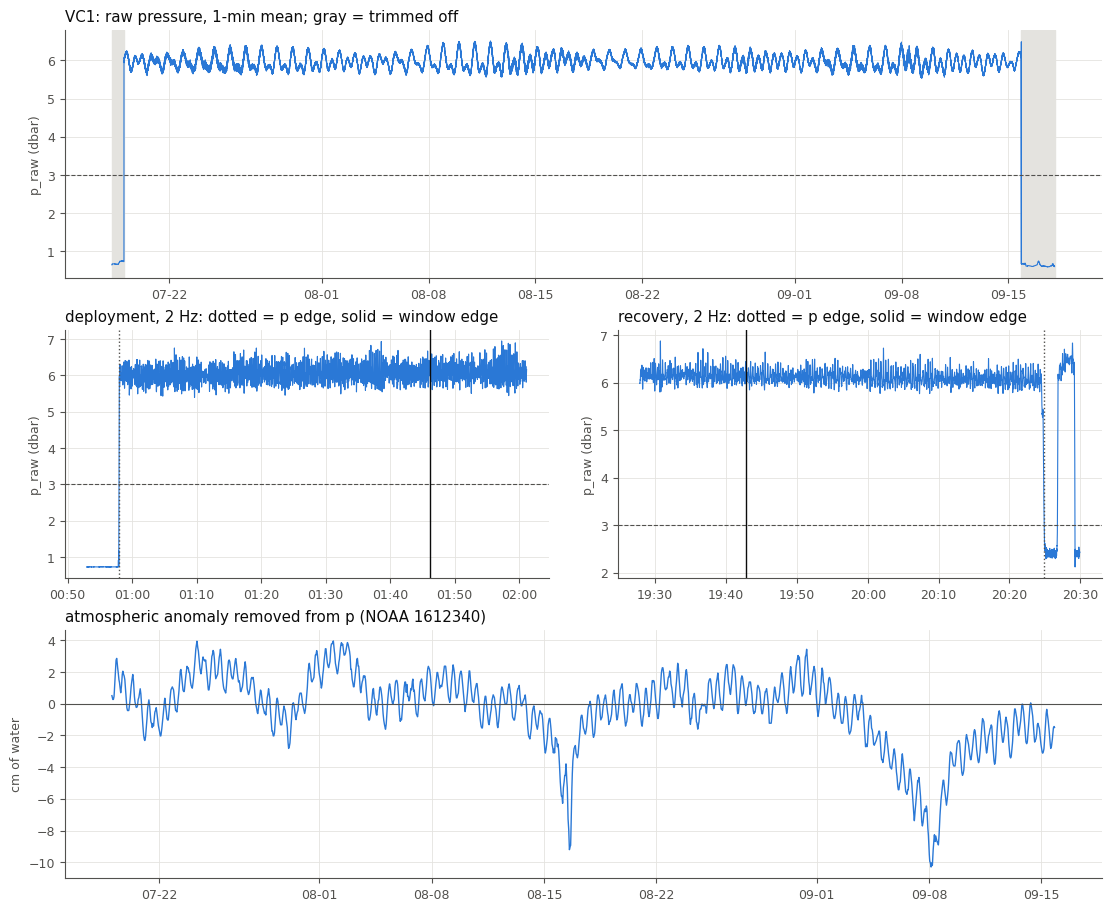

In [49]:
##-----figure: trim window + atmospheric correction-----##
# top row: whole raw record at 1-min means (10.7 M points is too many to draw); gray = cut
p1 = pd.Series(p_raw, index=t).resample("1min").mean()
fig = plt.figure(figsize=(11, 9), constrained_layout=True)
gs = fig.add_gridspec(3, 2)

ax = fig.add_subplot(gs[0, :])
ax.plot(p1.index, p1.values, color=SERIES, lw=0.8)
ax.axvspan(p1.index[0], t_in, color=GRID, zorder=0)
ax.axvspan(t_out, p1.index[-1], color=GRID, zorder=0)
ax.axhline(P_WET, color=INK2, ls="--", lw=0.8)
ax.set_ylabel("p_raw (dbar)")
ax.set_title(f"{sensor_id}: raw pressure, 1-min mean; gray = trimmed off", loc="left", color=INK)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))

# middle row: 2 Hz zooms around each end. Dotted = pressure edge (p >= 3 dbar),
# solid = final window edge after the handling cut + buffer
zooms = [(t[i_in] - pd.Timedelta(minutes=5), t_in + pd.Timedelta(minutes=15), t[i_in], t_in, "deployment"),
         (t_out - pd.Timedelta(minutes=15), t[i_out] + pd.Timedelta(minutes=5), t[i_out], t_out, "recovery")]
for j, (a, b, tp, te, lab) in enumerate(zooms):
    ax = fig.add_subplot(gs[1, j])
    w = (t > a) & (t < b)
    ax.plot(t[w], p_raw[w], color=SERIES, lw=0.8)
    ax.axhline(P_WET, color=INK2, ls="--", lw=0.8)
    ax.axvline(tp, color=INK2, ls=":", lw=1)
    ax.axvline(te, color=INK, lw=1)
    ax.set_title(f"{lab}, 2 Hz: dotted = p edge, solid = window edge", loc="left", color=INK)
    ax.set_ylabel("p_raw (dbar)")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

# bottom row: the barometric anomaly removed from p, in cm of water (10-min means)
ax = fig.add_subplot(gs[2, :])
a1 = pd.Series(100 * (patm_k - np.median(patm_k)), index=t[keep]).resample("10min").mean()
ax.plot(a1.index, a1.values, color=SERIES, lw=1)
ax.axhline(0, color=INK2, lw=0.8)
ax.set_ylabel("cm of water")
ax.set_title("atmospheric anomaly removed from p (NOAA 1612340)", loc="left", color=INK)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))

fig.savefig(fig_dir / f"{sensor_id}_trim.png", dpi=150)
plt.show()

#### 2b. Tide-gauge check of the corrected clock (coarse)
Cross-correlate the sensor's tide (1-min mean water level from `p`) with the NOAA CO-OPS 6-min
water level at Honolulu 1612340. A lag near 0 confirms the clock is UTC with no hour-scale or
time-zone error. It **cannot** resolve seconds: the tide is too slow, and Ewa and Honolulu Harbor
differ in tidal phase by minutes anyway. Seconds-level checking needs the co-located Signature 1000
(VC2 only: wave-band p–p cross-correlation, after the ADCP's own -6 s drift correction). That is
pending the ADCP data.

tide lag VC1 vs Honolulu: +0 min (r = 0.9856); tidal amplitude ratio sensor/gauge = 1.029


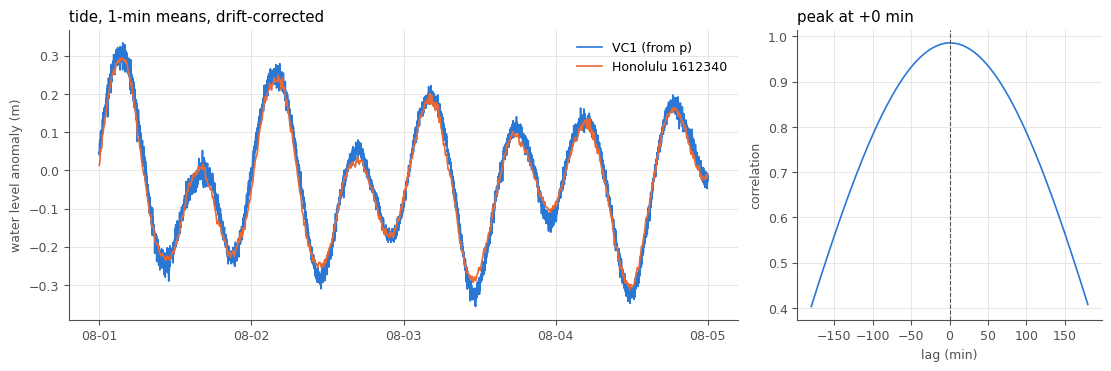

In [50]:
##-----tide-gauge check: coarse clock / time-zone test-----##
# NOAA CO-OPS 1612340 (Honolulu Harbor), 6-min water level relative to MSL, GMT. The API caps
# 6-min requests at 31 days, so fetch in chunks. Cached next to the barometer file.
wl_csv = root / "data" / "metadata" / "noaa_1612340_water_level.csv"
if not wl_csv.exists():
    parts = []
    for a, b in [("20260718", "20260817"), ("20260818", "20260917"), ("20260918", "20260919")]:
        url = ("https://api.tidesandcurrents.noaa.gov/api/prod/datagetter?product=water_level"
               f"&station=1612340&begin_date={a}&end_date={b}&datum=MSL&units=metric"
               "&time_zone=gmt&format=csv&application=4EWA")
        parts.append(pd.read_csv(url, skipinitialspace=True))
    pd.concat(parts).drop_duplicates("Date Time").to_csv(wl_csv, index=False)
wl = pd.read_csv(wl_csv, skipinitialspace=True, parse_dates=["Date Time"]).dropna(subset=["Water Level"])
gauge = wl.set_index("Date Time")["Water Level"]

# water level: hydrostatic p -> m of water (RHO, GRAV from the parameters cell),
# then 1-min means to average out the waves. The gauge's 6-min series is interpolated onto the
# same minutes. Only the tidal variation matters, so both are de-meaned.
eta = pd.Series(out.p.values * 1e4 / (RHO * GRAV), index=out.time.values).resample("1min").mean()
g_i = pd.Series(np.interp(eta.index.values.astype("int64"),
                          gauge.index.values.astype("int64"), gauge.values), index=eta.index)
eta_a, g_a = eta - eta.mean(), g_i - g_i.mean()

# correlation at lags of -3 h to +3 h in 1-min steps. Lag L compares the sensor at t with the gauge at
# t - L. The peak should sit at ~0; a +/-600 min peak would mean a Hawaii-time clock.
lags = np.arange(-180, 181)
r = np.array([eta_a.corr(g_a.shift(L)) for L in lags])
best = lags[np.argmax(r)]
print(f"tide lag {sensor_id} vs Honolulu: {best:+d} min (r = {r.max():.4f}); "
      f"tidal amplitude ratio sensor/gauge = {eta_a.std() / g_a.std():.3f}")
out.attrs["qc_clock_tide_lag_min"] = int(best)

# figure: left = 4-day overlay, right = correlation vs lag
fig, axs = plt.subplots(1, 2, figsize=(11, 3.6), constrained_layout=True,
                        gridspec_kw={"width_ratios": [2.2, 1]})
w = slice("2026-08-01", "2026-08-04")
axs[0].plot(eta_a[w].index, eta_a[w].values, color="#2a78d6", lw=1.2, label=f"{sensor_id} (from p)")
axs[0].plot(g_a[w].index, g_a[w].values, color="#eb6834", lw=1.2, label="Honolulu 1612340")
axs[0].set_ylabel("water level anomaly (m)")
axs[0].set_title("tide, 1-min means, drift-corrected", loc="left")
axs[0].legend(frameon=False)
axs[0].xaxis.set_major_locator(mdates.DayLocator())
axs[0].xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
axs[1].plot(lags, r, color="#2a78d6", lw=1.2)
axs[1].axvline(best, color="#52514e", ls="--", lw=0.8)
axs[1].set_xlabel("lag (min)")
axs[1].set_ylabel("correlation")
axs[1].set_title(f"peak at {best:+d} min", loc="left")
fig.savefig(fig_dir / f"{sensor_id}_clock_tide.png", dpi=150)
plt.show()

In [51]:
##-----save-----##
# zlib compression on every data variable (level 4: good size/speed tradeoff; ~0.18 GB per sensor).
# time is listed explicitly: replacing the coordinate (drift correction) dropped its compression
# settings, and uncompressed int64 time adds ~70 MB.
# Written to data/processed/qc/{sensor}_trim.nc: clock-corrected AND trimmed (sections 1 + 2).
# The untrimmed file in data/processed/ is untouched.
enc = {v: {"zlib": True, "complevel": 4} for v in out.data_vars}
enc["time"] = {"zlib": True, "complevel": 4}
out_path = qc_dir / f"{sensor_id}_trim.nc"
out.to_netcdf(out_path, encoding=enc)
print(f"saved {out_path}  ({out_path.stat().st_size / 1e9:.2f} GB)")

saved /Users/isidorarojas/Desktop/DIRECTORY/2026/4EWA/data/processed/qc/VC1_trim.nc  (0.19 GB)


### 3. Beam Quality masks
 - Correlation: the lab (NEVAEWA/Nortek_Vector_PUV_Pipeline) NaNs velocity where the minimum beam
   correlation is below 70% (Nortek recommendation; `corrMin = 70`, `valid_corr` in
   `L1_raw_to_qc/puv_channel_qc.m`). Also check low amplitude/SNR (burial, fouling, out of water).
   Watch for progressive correlation loss, which can be biofouling in warm water (CAT21A example
   in the lab's `PIPELINE_NOTES.md`).
 - Gate per channel, not per row. The lab's 2026-07 channel-decoupling rework lets pressure
   and velocity fail independently (`L1_raw_to_qc/puv_channel_qc.m`,
   `docs/OUTSTANDING_channel_decoupling.md`).
 - Report the % flagged per sensor and per hour, and plot it against time and Hs.

#### 3a. Correlation gate + amplitude diagnostic

Input is `out` from section 2 (clock-corrected, trimmed, atmosphere removed).
1. **Correlation gate (applied).** A velocity sample is kept only if **all three** beams have
   `corr >= CORR_MIN` (70 %), the lab's `valid_corr = min(corr) >= corrMin`. The gate is per
   sample, not per velocity component: in the instrument frame, u, v and w are each a combination
   of all three beam velocities, so one bad beam corrupts all three. Failed samples become NaN in
   u, v, w. Pressure and temperature are not touched (channel decoupling).
2. **Amplitude / SNR (diagnostic, not applied).** The lab does not gate on amplitude. Here
   `SNR ≈ 0.43 dB/count × (amp − noise floor)`, with the noise floor per beam taken as the median
   pre-deployment in-air amplitude. Samples where any beam is below `SNR_MIN` are stored in
   `vel_low_snr` and reported, but velocity is not NaN'd unless `APPLY_SNR = True`. Turn it on only
   if the figure shows low SNR catching something the correlation gate misses (e.g. burial).
3. **Diagnostics.** % flagged per hour against time and against `Hs_p`; daily median correlation
   and amplitude per beam (a steady decline = biofouling or burial); correlation histograms.
   `Hs_p = 4 × std` of bed pressure after a 5-min high-pass, in m of water. It is **not**
   corrected for depth attenuation, so it underestimates Hs (more for short waves). It is only used
   to see whether the flag rate tracks wave energy (bubbles, sediment, orbital velocities near the
   velocity range).
4. **Save** `{sensor}_beam.nc`.

In [52]:
##-----beam quality: correlation gate + amplitude diagnostic-----##
corr = out["corr"].values                 # (beam, time), %
amp  = out["amp"].values.astype(float)    # (beam, time), counts

# correlation, per beam, then per sample: all three beams must pass
corr_ok_beam = corr >= CORR_MIN
vel_ok = corr_ok_beam.all(axis=0)

# amplitude -> approximate SNR. Noise floor per beam = median in-air amplitude before deployment
# (`pre` from section 2: p_raw < P_AIR, > 5 min before the splash), where no echo comes back.
noise = np.median(ds["amp"].values[:, pre], axis=1)
snr = AMP_DB_PER_COUNT * (amp - noise[:, None])
low_snr = (snr < SNR_MIN).any(axis=0)

bad = ~vel_ok | (low_snr if APPLY_SNR else False)

# new dataset: u, v, w NaN'd where bad; everything else (p, temp, corr, amp, ...) as in `out`.
# `out` itself is left untouched, so re-running this cell with other thresholds is safe.
bq = out.copy()
keep_da = xr.DataArray(~bad, dims="time")
for c in ["u", "v", "w"]:
    bq[c] = out[c].where(keep_da)
    bq[c].attrs = dict(out[c].attrs, beam_qc=f"NaN where min beam corr < {CORR_MIN} %"
                       + (f" or any beam SNR < {SNR_MIN} dB" if APPLY_SNR else ""))
bq["vel_corr_ok"] = xr.DataArray(vel_ok, dims="time",
    attrs={"long_name": f"all three beam correlations >= {CORR_MIN} %"})
bq["vel_low_snr"] = xr.DataArray(low_snr, dims="time",
    attrs={"long_name": f"any beam SNR < {SNR_MIN} dB", "applied": str(APPLY_SNR)})
bq.attrs.update({
    "qc_beam_corr_min_pct": CORR_MIN,
    "qc_beam_snr_min_db": SNR_MIN,
    "qc_beam_snr_applied": str(APPLY_SNR),
    "qc_beam_amp_noise_floor_counts": ", ".join(f"{x:.0f}" for x in noise),
    "qc_beam_vel_flagged_pct": float(100 * bad.mean()),
})

# gaps: lengths of consecutive flagged runs (matters for how despiking/interpolation treats them)
g0, g1 = runs(bad)
glen = g1 - g0 + 1

n = bad.size
print(f"{sensor_id}: velocity flagged in {100 * bad.mean():.2f} % of {n:,} in-water samples")
for b in range(3):
    print(f"  beam {b + 1}: corr < {CORR_MIN} % in {100 * (~corr_ok_beam[b]).mean():.2f} %, "
          f"median corr {np.median(corr[b]):.0f} %, noise floor {noise[b]:.0f} counts, "
          f"median SNR {np.median(snr[b]):.1f} dB")
print(f"  low SNR (< {SNR_MIN} dB, any beam): {100 * low_snr.mean():.2f} % "
      f"({100 * (low_snr & vel_ok).mean():.2f} % NOT already caught by correlation) -> "
      f"{'applied' if APPLY_SNR else 'diagnostic only'}")
if glen.size:
    print(f"  flagged runs: {glen.size:,}; median {np.median(glen):.0f} samples, "
          f"{100 * (glen <= 4).mean():.0f} % are <= 4 samples (2 s), longest {glen.max():,} "
          f"samples ({glen.max() / float(ds.attrs['fs']) / 60:.1f} min)")

VC1: velocity flagged in 2.32 % of 10,151,599 in-water samples
  beam 1: corr < 70 % in 1.47 %, median corr 97 %, noise floor 42 counts, median SNR 29.7 dB
  beam 2: corr < 70 % in 0.84 %, median corr 96 %, noise floor 42 counts, median SNR 28.8 dB
  beam 3: corr < 70 % in 2.08 %, median corr 95 %, noise floor 43 counts, median SNR 26.2 dB
  low SNR (< 5.0 dB, any beam): 1.78 % (0.13 % NOT already caught by correlation) -> diagnostic only
  flagged runs: 58,204; median 1 samples, 82 % are <= 4 samples (2 s), longest 790 samples (6.6 min)


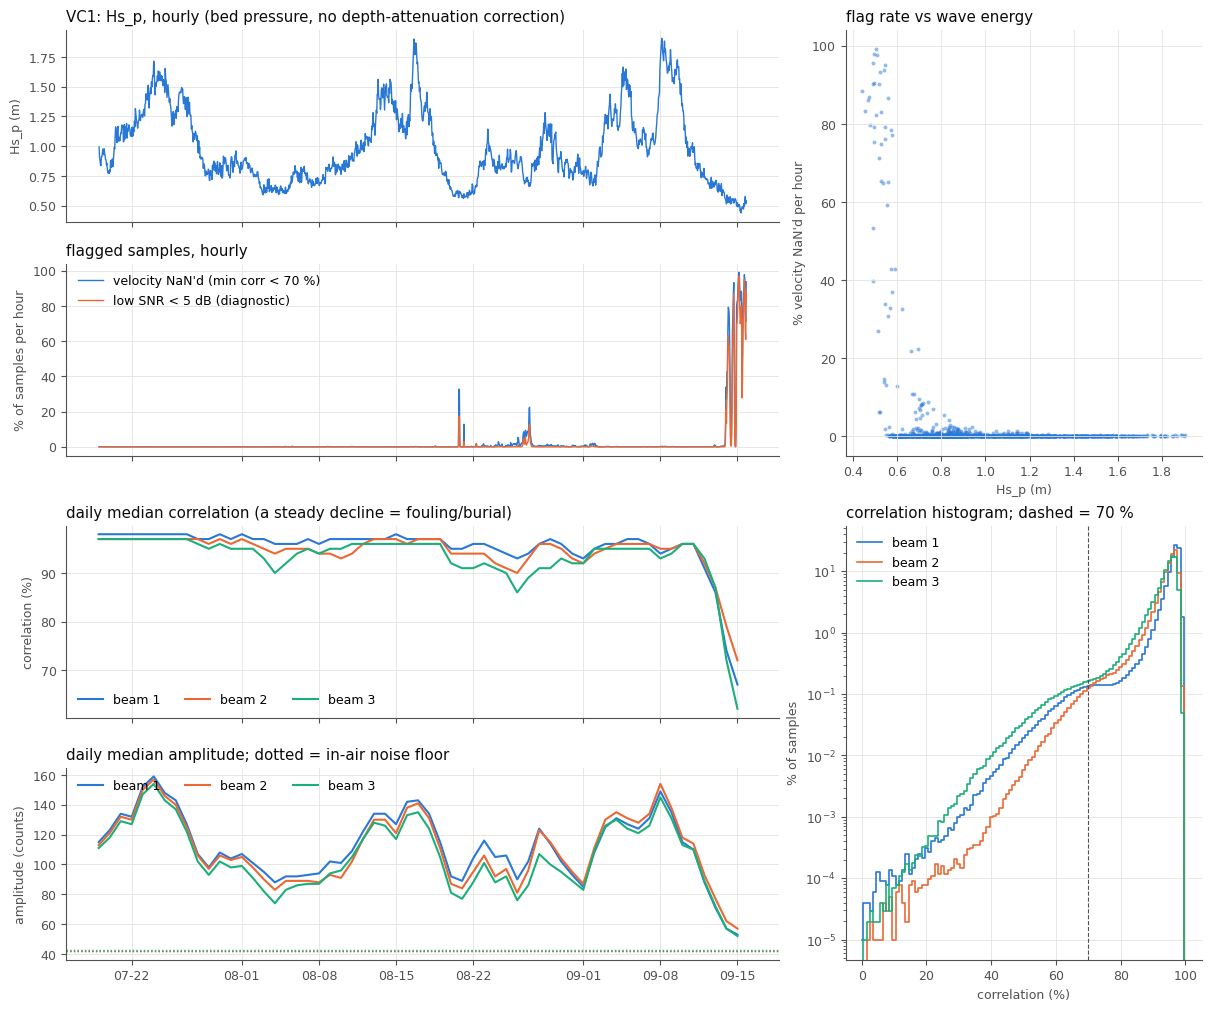

hourly flag rate: median 0.03 %, max 99.2 % (2026-09-15 03:00:00); corr with Hs_p r = -0.26


In [53]:
##-----figure: beam quality over the deployment-----##
tq = pd.DatetimeIndex(bq.time.values)
fs = float(ds.attrs["fs"])

# Hs_p: 4 * std of bed pressure after a 5-min high-pass (removes tide), per hour, m of water.
# NOT corrected for depth attenuation: a wave-energy proxy only.
p_s = pd.Series(out.p.values.astype(float), index=tq)
p_hp = p_s - p_s.rolling(int(300 * fs), center=True, min_periods=int(60 * fs)).mean()
hs_p = 4 * p_hp.resample("1h").std() * 1e4 / (RHO * GRAV)

flag_h = 100 * pd.Series(bad, index=tq).resample("1h").mean()
snr_h  = 100 * pd.Series(low_snr, index=tq).resample("1h").mean()
corr_d = pd.DataFrame(corr.T, index=tq).resample("1D").median()
amp_d  = pd.DataFrame(amp.T, index=tq).resample("1D").median()

fig = plt.figure(figsize=(12, 10), constrained_layout=True)
gs = fig.add_gridspec(4, 3)

# left column: time series, shared x
ax0 = fig.add_subplot(gs[0, :2])
ax0.plot(hs_p.index, hs_p.values, color=SERIES, lw=1)
ax0.set_ylabel("Hs_p (m)")
ax0.set_title(f"{sensor_id}: Hs_p, hourly (bed pressure, no depth-attenuation correction)",
              loc="left", color=INK)

ax1 = fig.add_subplot(gs[1, :2], sharex=ax0)
ax1.plot(flag_h.index, flag_h.values, color=BEAM_COLORS[0], lw=1,
         label=f"velocity NaN'd (min corr < {CORR_MIN} %)")
ax1.plot(snr_h.index, snr_h.values, color=BEAM_COLORS[1], lw=1,
         label=f"low SNR < {SNR_MIN:g} dB ({'applied' if APPLY_SNR else 'diagnostic'})")
ax1.set_ylabel("% of samples per hour")
ax1.set_title("flagged samples, hourly", loc="left", color=INK)
ax1.legend(frameon=False, loc="upper left")

ax2 = fig.add_subplot(gs[2, :2], sharex=ax0)
for b in range(3):
    ax2.plot(corr_d.index, corr_d[b].values, color=BEAM_COLORS[b], lw=1.5, label=f"beam {b + 1}")
ax2.set_ylabel("correlation (%)")
ax2.set_title("daily median correlation (a steady decline = fouling/burial)", loc="left", color=INK)
ax2.legend(frameon=False, loc="lower left", ncol=3)

ax3 = fig.add_subplot(gs[3, :2], sharex=ax0)
for b in range(3):
    ax3.plot(amp_d.index, amp_d[b].values, color=BEAM_COLORS[b], lw=1.5, label=f"beam {b + 1}")
    ax3.axhline(noise[b], color=BEAM_COLORS[b], ls=":", lw=1)
ax3.set_ylabel("amplitude (counts)")
ax3.set_title("daily median amplitude; dotted = in-air noise floor", loc="left", color=INK)
ax3.legend(frameon=False, loc="upper left", ncol=3)
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
for a in (ax0, ax1, ax2):
    a.tick_params(labelbottom=False)

# right column: flag rate vs wave energy, and correlation histograms
ax4 = fig.add_subplot(gs[:2, 2])
both = pd.concat([hs_p.rename("hs"), flag_h.rename("f")], axis=1).dropna()
ax4.scatter(both.hs, both.f, s=8, color=SERIES, alpha=0.5, lw=0)
ax4.set_xlabel("Hs_p (m)")
ax4.set_ylabel("% velocity NaN'd per hour")
ax4.set_title("flag rate vs wave energy", loc="left", color=INK)

ax5 = fig.add_subplot(gs[2:, 2])
bins = np.arange(0, 102)
for b in range(3):
    h = np.bincount(corr[b], minlength=101)[:101]
    ax5.step(bins[:-1], 100 * h / h.sum(), where="mid", color=BEAM_COLORS[b], lw=1.2,
             label=f"beam {b + 1}")
ax5.axvline(CORR_MIN, color=INK2, ls="--", lw=0.8)
ax5.set_yscale("log")
ax5.set_xlabel("correlation (%)")
ax5.set_ylabel("% of samples")
ax5.set_title(f"correlation histogram; dashed = {CORR_MIN} %", loc="left", color=INK)
ax5.legend(frameon=False, loc="upper left")

fig.savefig(fig_dir / f"{sensor_id}_beam.png", dpi=150)
plt.show()
print(f"hourly flag rate: median {flag_h.median():.2f} %, max {flag_h.max():.1f} % "
      f"({flag_h.idxmax()}); corr with Hs_p r = {both.hs.corr(both.f):.2f}")

In [54]:
##-----save-----##
# same compression as section 2. u, v, w are NaN'd where flagged; the unmasked values are in
# {sensor}_trim.nc. Flags are saved so the mask can be re-derived or combined later.
enc = {v: {"zlib": True, "complevel": 4} for v in bq.data_vars}
enc["time"] = {"zlib": True, "complevel": 4}
out_path = qc_dir / f"{sensor_id}_beam.nc"
bq.to_netcdf(out_path, encoding=enc)
print(f"saved {out_path}  ({out_path.stat().st_size / 1e9:.2f} GB)")

saved /Users/isidorarojas/Desktop/DIRECTORY/2026/4EWA/data/processed/qc/VC1_beam.nc  (0.19 GB)


### 4. Despiking
 - Order: despike in the instrument frame, before rotation. Rotation smears a spike on one beam into all components.
 - Method: Goring & Nikora (2002) phase-space thresholding, modified by Wahl (2003). Mori, Suzuki & Kakuno (2007) is the variant for bubbly/wave conditions. dolfyn 1.3.0 has dolfyn.adv.clean.GN2002, spike_thresh, range_limit, clean_fill (verified present).
 - At 2 Hz in waves, GN2002's "universal threshold" assumes a spiky turbulence signal sampled fast. Real orbital-velocity crests can be flagged. Apply it to a residual (detrended or high-passed about the wave-band signal, or per short window), or tune the threshold. Inspect flagged points overlaid on raw data during the largest-wave hours.
 - Replace only short runs (interpolate ≲ a few samples). Leave longer gaps as NaN. Record % replaced per segment; the lab drops segments with >10% NaN before spectra (nanMaxFrac).
 - Surf-zone ADV QC context: Elgar, Raubenheimer & Guza (2001, 2005) and Feddersen (2010).

 ### 5. Tilt / attitude
 - The internal sensors describe the canister, not the head. These are
   cable-head Vectors and the canister lies nearly horizontal (VB1 pitch/roll about ±165°). dolfyn's orientmat and orientation_down bit reflect the housing, so they are not valid for rotating head-frame velocity. Check the orientation_down counts from the slim step.
 - dolfyn: set_inst2head_rotmat exists for cable heads (verified in 1.3.0). Without a measured head attitude, assume the head is vertical 
 - Use canister tilt as a motion detector, not a correction: a rolling std of pitch/roll (the lab flags >2° over 60 s), and heading steps. The VD2 compass step near 09-08 means the frame or head moved. Split the record there and check it.
 - Loose heads (VB1, VE1, VE2): the head could rotate independently of the
   canister, so the compass can't show it. Detect from the data: track std(w)/std(u) (tilt leakage) and the wave/current principal-axis direction per day. A step means head motion.

### 6. Rotation to earth/shore-normal 

- Rotate XYZ coords to earth coordinates usingg KVH magnetic heading + declination. 
- Then rotate to shore-normal coordinates
 - Verify the heading physically. This is how the lab caught its 180° errors:
   a. p–u co-spectrum phase ≈ 0 and sign consistent with onshore-propagating swell (south swell at Ewa) [lit/: Elgar & Guza 1985; Sheremet et al. 2002].
   b. The mean-current principal axis should be ~alongshore. The lab ranks this above wave-direction estimators (PIPELINE_NOTES.md, "Deriving a shore-normal"). Use
      dolfyn.calc_principal_heading. Check anisotropy: ≈1 means the axis is meaningless.
   c. VC2 vs the co-located Signature 1000 ADCP: mean current and wave
      direction should agree after rotation.
   d. Mean wave direction should be consistent across the array (no one sensor 90°/180° off).

### Z-Test, Linear Wave Theory etc...
- $$Z = \Sigma S_{pp}*S_{\eta} / \Sigma S_{pp_exp} $$
- $$ S_{pp_pred} = (S_{uu}+S_{vv})·(\omega/gk)²·[cosh(k z_p)/cosh(k z_u)]²$$

### Run the other sensors
Off by default. Once the pipeline is verified on VC1:
1. fill `SENSORS` in the parameters cell (section 0),
2. save the notebook (the batch cell reads it from disk),
3. set `RUN_BATCH = True` in the cell below and run that cell on its own.

Each sensor runs in a fresh kernel, with `sensor_id` overridden. The executed copy, with all
printed QC numbers and figures, goes to `processing/qc_runs/adv_QC_{sensor}.ipynb`, so each sensor
can be reviewed the same way VC1 was. Thresholds tuned on VC1/VC2 (e.g. `HEAD_STD_MAX`) should be
checked in each copy.

In [55]:
##-----batch: run this notebook once per sensor in SENSORS-----##
RUN_BATCH = False

if RUN_BATCH:
    import nbformat
    from nbclient import NotebookClient
    nb_path = root / "processing" / "adv_QC.ipynb"
    run_dir = root / "processing" / "qc_runs"
    run_dir.mkdir(exist_ok=True)
    for sid in SENSORS:
        nb = nbformat.read(nb_path, as_version=4)
        # drop this cell from the copy (no recursion) and override sensor_id in the parameters cell
        nb.cells = [c for c in nb.cells if "batch" not in c.metadata.get("tags", [])]
        par = next(c for c in nb.cells if "parameters" in c.metadata.get("tags", []))
        par.source += f'\nsensor_id = "{sid}"   # injected by the batch cell'
        print(f"{sid}: running ...", flush=True)
        try:
            NotebookClient(nb, timeout=None, kernel_name="analysiz",
                           resources={"metadata": {"path": str(nb_path.parent)}}).execute()
            print(f"{sid}: ok")
        except Exception as e:   # keep going; the error is in the saved copy
            print(f"{sid}: FAILED ({type(e).__name__}), see the saved copy")
        nbformat.write(nb, run_dir / f"adv_QC_{sid}.ipynb")